# Esercizio 3.3 - Pretraining ResNet-50 per GTSRB

In questo notebook riutilizziamo la pipeline Lightning/WandB per addestrare una **ResNet-50** sul task di classificazione GTSRB.
Il checkpoint con F1 macro di validazione migliore viene riutilizzato nel notebook `04_faster_rcnn_training.ipynb` per inizializzare il corpo ResNet-50 del detector.

- **`src.lightning_modules.LitResNet`**: contiene la logica di addestramento per la classificazione.
- **`config.yaml`**: contiene gli iperparametri dell'esperimento ResNet-50 gestiti via `OmegaConf`.
- **WandB**: registra curve di loss, accuracy e F1 per confrontare il pretraining con gli esperimenti precedenti.

In [5]:
import sys
if '..' not in sys.path:
    sys.path.append('..')

import torch
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint
import wandb
from omegaconf import OmegaConf

from src.dataset import get_dataloaders, get_class_weights
from src.lightning_modules import LitResNet
from src.utils import set_seed

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ottimizzazione per Tensor Cores (RTX serie 3000/4000)
torch.set_float32_matmul_precision('medium')

# Caricamento della configurazione da YAML
cfg = OmegaConf.load('config.yaml')
print(OmegaConf.to_yaml(cfg))

dataset:
  data_dir: ../_data
  batch_size: 256
  num_workers: 6
  augmentation: heavy_blur
model:
  name: resnet50
  num_classes: 43
  pretrained: true
training:
  epochs: 50
  lr: 0.0001
  optimizer: adamw
  label_smoothing: 0.1
  use_onecycle_lr: true
  use_class_weights: true
  early_stopping_patience: 5
logging:
  project_name: DeepLearningApplicationLab1
  run_name: resnet50_gtsrb_pretraining



## 1. Caricamento Dataset

Carichiamo i DataLoader usando batch size, directory dati e strategia di augmentation definiti in `config.yaml`.

In [6]:
train_dl, val_dl, test_dl = get_dataloaders(
    data_dir=cfg.dataset.data_dir,
    batch_size=cfg.dataset.batch_size,
    num_workers=cfg.dataset.num_workers,
    augmentation_strategy=cfg.dataset.augmentation,
    device=device
)

## 2. Inizializzazione ResNet-50 e Addestramento

Inizializziamo `LitResNet` con `model_name=cfg.model.name`, quindi addestriamo ResNet-50 con logging WandB e monitoraggio delle metriche di validazione.

In [3]:
from pytorch_lightning.callbacks import TQDMProgressBar

from pytorch_lightning.callbacks.early_stopping import EarlyStopping

# Otteniamo i pesi delle classi per bilanciare la loss
class_weights = get_class_weights(cfg.dataset.data_dir)


# Inizializziamo il modulo passando esplicitamente i parametri (massima modularità)
lit_model = LitResNet(model_name=cfg.model.name, 
    num_classes=cfg.model.num_classes, 
    pretrained=cfg.model.pretrained,
    lr=cfg.training.lr,
    class_weights=class_weights,
    optimizer_name=cfg.training.optimizer,
    label_smoothing=0.1,
    use_onecycle_lr=True,
)

# Inizializziamo il Logger di WandB. log_model=True carica automaticamente su WandB
# il checkpoint migliore salvato da ModelCheckpoint, come backup versionato in cloud.
wandb_logger = WandbLogger(
    project=cfg.logging.project_name, 
    name=cfg.logging.run_name,
    config=OmegaConf.to_container(cfg, resolve=True),
    log_model=True,
)

# Logger CSV locale in parallelo a WandB: le curve restano disponibili anche offline.
csv_logger = CSVLogger(save_dir="logs", name="resnet50_pretraining", version=0)

# Inizializziamo il Trainer associando il logger e la barra avanzata
# Configurazione Early Stopping
early_stop_callback = EarlyStopping(
    monitor="val/loss",
    min_delta=0.00,
    patience=5,
    verbose=False,
    mode="min"
)

# Salviamo il checkpoint con il miglior F1-score macro di validazione: questo e' il peso
# che verra' poi riutilizzato come backbone della Faster R-CNN nel notebook successivo.
checkpoint_callback = ModelCheckpoint(
    monitor="val_f1_score",
    mode="max",
    dirpath="checkpoints/",
    filename="resnet50_gtsrb-{epoch:02d}-{val_f1_score:.3f}",
    save_top_k=1,
)

# Forziamo TQDM per risolvere i conflitti visivi di Rich in VS Code
progress_bar = TQDMProgressBar(refresh_rate=10)

trainer = pl.Trainer(
    max_epochs=cfg.training.epochs,
    accelerator="auto",
    precision="16-mixed",
    logger=[wandb_logger, csv_logger],
    callbacks=[early_stop_callback, checkpoint_callback, progress_bar],
    log_every_n_steps=10
)

# Avvio della sperimentazione.
print('Avvio esperimento monitorato su WandB...')
trainer.fit(lit_model, train_dataloaders=train_dl, val_dataloaders=val_dl)

# Valutiamo il checkpoint con F1 macro migliore, non lo stato dell'ultima epoca.
print('\nInizio calcolo metriche di Validation finali...')
trainer.validate(dataloaders=val_dl, ckpt_path="best")

# Esecuzione finale sul test set puro.
print('\nInizio test finale...')
trainer.test(dataloaders=test_dl, ckpt_path="best")

wandb.finish()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\franc\.netrc.


Avvio esperimento monitorato su WandB...


wandb: Currently logged in as: francescoberaldi01 (francescoberaldi01-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\.venv-windows\Lib\site-packages\lightning_fabric\loggers\csv_logs.py:268: Experiment logs directory logs\resnet50_pretraining\version_0 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
c:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\.venv-windows\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\DLA_LAB1\exercise_3_gtsrb_detection\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\.venv-windows\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated 

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet             │ 23.6 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
│ 6 │ test_f1   │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

...

Restoring states from the checkpoint path at C:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\DLA_LAB1\exercise_3_gtsrb_detection\checkpoints\resnet50_gtsrb-epoch=13-val_f1_score=0.999-v3.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at C:\Users\franc\Desktop\Git_Hub_Deep_Learning-Applications_Francesco_Beraldi\DLA_LAB1\exercise_3_gtsrb_detection\checkpoints\resnet50_gtsrb-epoch=13-val_f1_score=0.999-v3.ckpt



Inizio test finale...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/accuracy       │    0.9847980737686157     │
│       test/f1_score       │    0.9780248999595642     │
│         test/loss         │    1.1691924333572388     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇████
test/accuracy,▁
test/f1_score,▁
test/loss,▁
train/accuracy,▁▅▇████████████
train/f1_score,▁▅▇████████████
train/loss_epoch,█▄▂▁▁▁▁▁▁▁▁▁▁▁▁
train/loss_step,█▇▆▅▄▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
val/accuracy,▁▇██████████████
+3,...


## 3. Curve di Training

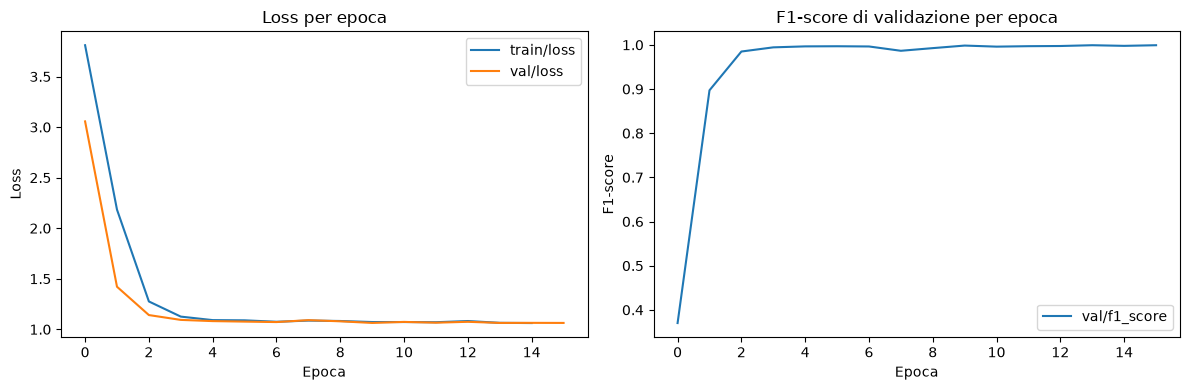

In [4]:
from src.utils import load_epoch_metrics
import matplotlib.pyplot as plt

metrics = load_epoch_metrics("logs/resnet50_pretraining/version_0/metrics.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(metrics.index, metrics["train/loss_epoch"], label="train/loss")
axes[0].plot(metrics.index, metrics["val/loss"], label="val/loss")
axes[0].set_title("Loss per epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(metrics.index, metrics["val_f1_score"], label="val/f1_score")
axes[1].set_title("F1-score di validazione per epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("F1-score")
axes[1].legend()

plt.tight_layout()
plt.show()

**Osservazioni**

- Val/accuracy 0,9991, val/F1 0,9992, val/loss 1,064.
- Test/accuracy 0,9848, test/F1 0,9780, test/loss 1,169.
- Early stopping attivato su val/loss (patience 5): training fermato a 15 epoche, su 50 massime configurate.
- Il checkpoint migliore (F1 macro di validazione) resta indipendente dalla pipeline di detection: vedi nota a inizio notebook.